<center><h2><strong><font color="blue"> Data Engineering for Data Science</font></strong></h2></center>

<center><img alt="" src="images/cover.png" style="height: 360px;"/></center>

<center><h2><strong><font color="blue">DEDS-02: Writing Production-Grade Python</font></strong></h2></center>

<b><center><h3>(C) Taufik Sutanto</h3></center>

<center><h2><strong><font color="blue">Outline</font></strong></h2></center>

* Motivation
* Cookiecutter Data Science
* Modular programming: Functions, Classes, and Modules vs. Monolithic scripts.
* PEP8, Linting (flake8, black), and Type Hinting.

**Exercise/Assignment**
> Refactor Last Semester APDS Final Assignment into a structured, modular Python project.

<center><h2><strong><font color="blue">Whats wrong with this setup?</font></strong></h2></center>

<center><img alt="" src="images/deds-02/notebook_mess_example.png" style="height: 480px;"/></center>

<center><h2><strong><font color="blue">Why Structuring and Using Standard(s) on Our Data Science Projects' Assets?</font></strong></h2></center>

* **Ensuring Research Reproducibility**: Ad-hoc scripts and monolithic notebook environments frequently produce inconsistent and irreproducible results. Implementing production-grade standards ensures that data pipelines and analytical experiments can be independently verified by other researchers.
* **Enabling Scalability**: Shifting from monolithic scripts to modular programming frameworks—utilizing discrete functions, classes, and modules—allows research infrastructure to handle complex, large-scale datasets efficiently.
* **Facilitating Collaboration**: The adoption of standardized project directory structures and strict coding conventions, such as PEP8 and automated linting, streamlines peer review and collaborative development within research teams.
* **Guaranteeing Environment** Consistency: The application of virtual environments prevents software dependency conflicts. This isolation guarantees that research code executes identically across different computational hardware and operating systems.

<center><img alt="" src="images/deds-02/why-structuring-standard-important-datascience-projects.png" style="height: 480px;"/></center>

### The following video further illustrates the motivation within a real-world context (First 4 Minutes)

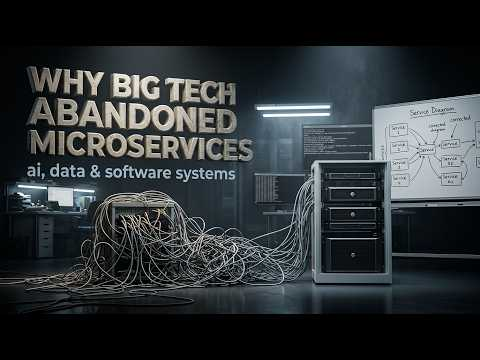

In [6]:
from IPython.display import YouTubeVideo

YouTubeVideo('ILXcsNxbas4', width=640, height=320)

<center><h2><strong><font color="blue">I. Data Science Project Structure</font></strong></h2></center>

A standard data science project logically isolates distinct workflow components. The fundamental structure typically includes:

* **Data Directory**: Segregates raw, immutable data from processed datasets. This guarantees data provenance and prevents accidental modification of primary sources.
* **Source Code (src)**: Contains modular, production-ready scripts. This directory houses the core logic, functions, and classes, strictly separated from exploratory work.
* **Notebooks**: Restricted solely to exploratory data analysis and final visualizations. Notebooks must not contain primary pipeline logic.
* **Outputs**: Stores generated artifacts, including trained models, evaluated metrics, and exported figures.
* **Configuration and Documentation**: The root directory must contain dependency lists (e.g., requirements.txt) and a comprehensive README.md to instruct reviewers and collaborators.

Implementing this separation of concerns ensures that the transition from initial data exploration to automated data pipelines remains systematic and verifiable.
    
<center><img alt="" src="images/deds-02/DataScience-Project-Structure.png" style="height: 480px;"/></center>

<center><h3><strong><font color="red"><i>But Which Structure?</i></font></strong></h3></center>

<center><h2><strong><font color="blue">The CookieCutter</font></strong></h2></center>

Cookiecutter automates the creation of a project directory tree. It utilizes predefined templates, replacing manual folder creation with an interactive, variable-driven process. The "Cookiecutter" standard for Data Science provides a widely accepted framework for organizing analytical research.
* https://github.com/cookiecutter/cookiecutter
* https://github.com/audreyfeldroy/cookiecutter-pypackage
    
<center><img alt="" src="images/deds-02/cookieCutter-logo.jpg" style="height: 100px;"/></center>

### Case Study: Establishing a Research Repository
Consider a data engineering project aimed at analyzing regional climate records. A researcher must establish a directory supporting data ingestion, processing scripts, and final reports.

Relying on manual setup often yields inconsistent structures. By deploying a Cookiecutter template, the researcher instantly generates a logical hierarchy—separating raw data, source code, and outputs—facilitating immediate, organized development.

### Step-by-Step Implementation
The following instructions outline the practical deployment of Cookiecutter.

<center><h2><strong><font color="blue">A. Installation</font></strong></h2></center>

Install the package within your system or **virtual environment terminal** using the standard Python package manager.

```bash
pip install cookiecutter-data-science

<center><h2><strong><font color="blue">B. Template Retrieval and Execution </font></strong></h2></center>

Execute the tool by pointing it to a relevant repository. The DrivenData data science template is a standard choice for analytical work.

### Please refer to the image below; for now, you may disregard the answer choices.

```bash
ccds

<center><img alt="" src="images/deds-02/ccds.jpg" style="height: 480px;"/></center>

<center><h2><strong><font color="blue">C. Resulting Infrastructure </font></strong></h2></center>

The tool automatically generates a comprehensive, modular project directory based on your inputs. You can then upload this structure to Git(Hub).

<center><img alt="" src="images/deds-02/structure.jpg" style="height: 320px;"/></center>

<center><h2><strong><font color="blue"> Python Virtual Environment </font></strong></h2></center>


The implementation of a virtual environment is a critical procedure following the establishment of the project directory. This practice guarantees dependency isolation, a fundamental requirement for reproducible research. A virtual environment functions as a sealed container. It prevents conflicts between software libraries utilized across different projects, resolving the common hardware and software compatibility errors.

The easiest way to set up the environment is by using Anaconda Navigator. However, careful attention must be paid to the requirements.txt file. How can this issue be addressed? ===> YAML

<center><img alt="" src="images/deds-02/Anaconda-env-Generator.jpg" style="height: 320px;"/></center>

# Using Requirements.txt to Create vEnv from a Terminal

From the directory in which the structure was created, execute the following commands in a terminal.

``` bash
conda create --name ds_env python=3.13
conda activate ds_env
conda install --file requirements.txt

<center><h2><strong><font color="blue"> II. Modular Programming — From Notebook Logic to Production Logic </font></strong></h2></center>

## A. The Starting Point: The Monolithic Script
Imagine a researcher analyzing climate data. They often start with a "monolith" where everything—data loading, cleaning, and plotting—happens in one long sequence.

The Problem: If you want to reuse the "cleaning" logic for a different dataset, you have to copy-paste the code. If you find a bug in the cleaning logic, you have to fix it in every file you pasted it into.

Example: The "Messy" Monolith
```python
# climate_analysis.py
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv("raw_data.csv")

# 2. Clean Data (The logic is "stuck" here)
df['temperature'] = df['temperature'].fillna(df['temperature'].mean())
df['date'] = pd.to_datetime(df['date'])

# 3. Plot
plt.plot(df['date'], df['temperature'])
plt.show()

## B. Step 1: Functional Modularization
The first step toward "Production-Grade" code is wrapping specific tasks into functions. This allows you to call the logic whenever needed without rewriting it.

The Transformation
We take the cleaning logic and put it inside a dedicated function.
```python
def clean_climate_data(data_frame):
    """Cleans temperature and date columns."""
    data_frame['temperature'] = data_frame['temperature'].fillna(data_frame['temperature'].mean())
    data_frame['date'] = pd.to_datetime(data_frame['date'])
    return data_frame

# Now the main script is cleaner
df = pd.read_csv("raw_data.csv")
df_cleaned = clean_climate_data(df)

## C. Step 2: Creating Modules (.py files)
Functions are great, but if you have 50 functions in one file, you’re back to a monolith. In production-grade Python, we move related functions into separate files called Modules.

Following our project structure, we move our logic into the src/ directory.

File 1: ***src/data_processing.py*** (The Module)
```python
# This file only contains logic, it doesn't "run" anything yet.
import pandas as pd

def clean_climate_data(df):
    df['temperature'] = df['temperature'].fillna(df['temperature'].mean())
    df['date'] = pd.to_datetime(df['date'])
    return df

### File 2: main.py (The Coordinator)

```python
# We "import" the logic from our module
from src.data_processing import clean_climate_data
import pandas as pd

df = pd.read_csv("data/raw/climate.csv")
df_cleaned = clean_climate_data(df) # Executing the modular logic

## D. Step 3: Organizing with Classes
For more complex research, we use Classes to group data and behavior together. This is particularly useful when your "processor" needs to remember settings (like a specific API key or a baseline temperature).

```python
class ResearchProcessor:
    def __init__(self, baseline_temp):
        self.baseline = baseline_temp

    def calculate_anomaly(self, current_temp):
        return current_temp - self.baseline

# Usage
processor = ResearchProcessor(baseline_temp=15.0)
anomaly = processor.calculate_anomaly(18.5)

### Why This Matters for Research
Mastering modularization is not just about "neatness"; it is a requirement for Engineering Reproducible Code.

* **Testability**: You can test the clean_climate_data function in isolation to ensure it works perfectly before using it on 1TB of data.
* **Collaboration**: One student can work on the scraping_module.py while another works on visualization_module.py without interfering with each other's code.
* **Maintenance**: If the data format changes, you only update the code in one module, and the change propagates through your entire pipeline.

<center><img alt="" src="images/deds-02/modularization.png" style="height: 320px;"/></center>

<center><h2><strong><font color="blue">III. Ensuring Code Quality — PEP8, Linting, and Type Hinting</font></strong></h2></center>

Adopting professional coding standards is a prerequisite for "Production-Grade" research. This module covers the tools and conventions that ensure your code is readable, maintainable, and robust.

### A. PEP8: The Python Style Guide
PEP8 is the official style guide for Python code. Its primary goal is to improve the readability of code, making it easier for research teams to collaborate.

Key Conventions:
* **Indentation**: Use 4 spaces per indentation level.
* **Variable Naming**: Use snake_case for variables and functions; use PascalCase for classes.
* **Line Length**: Limit all lines to a maximum of 79 characters.
* **Whitespace**: Avoid extraneous whitespace inside parentheses or immediately before a comma.

Example: Non-Compliant vs. PEP8 Compliant
```python
# Bad: Hard to read, inconsistent spacing
def my_function(x,y):
 return x+y

# Good: Clear, standard spacing
def my_function(x, y):
    return x + y

## B. Linting with flake8
A "linter" is a tool that analyzes source code to flag programming errors, bugs, stylistic errors, and suspicious constructs. flake8 acts as a reviewer. It does not change your code; it simply reports what is wrong.

How to use it:
* **Install**: *pip install flake8*
* **Run**: *flake8 script_name.py*

If your code violates PEP8 or contains logic errors (like an unused variable), flake8 will provide a list of "offenses" with line numbers.

## Please pause at this point and practice using the “messy” code provided above.

<center><img alt="" src="images/stop-exercise-learn.jpg" style="height: 320px;"/></center>

<center><h2><strong><font color="blue"> Auto formatting with Black - Ensuring Consistent Code Style </font></strong></h2></center>

In previous modules, we discussed PEP8, the official Python style guide, and linting (with tools like flake8), which identifies potential style violations and errors in your code. Now, we introduce Black, an extremely popular and effective tool that takes a different approach: auto-formatting.

Instead of just telling you what is wrong, Black takes your Python code and automatically reformats it to adhere to a strict and opinionated standard (which includes PEP8 and additional rules focused on readability and consistent structure). Black is known as "The Uncompromising Code Formatter" for a reason—it simplifies styling decisions for teams by making all code look the same, reducing the time spent discussing formatting during code reviews.

Why Use Black?
* **Consistency**: Every file formatted with Black looks identical, making it easier for research teams to collaborate on the same codebase without navigating different coding styles.
* **Readability**: Black enforces formatting (like consistent indentation and spacing) that is generally considered very readable, especially for complex code.
* **Automation**: You don't have to manually apply PEP8 rules; Black handles it with a single command. Integrating it into your workflow (e.g., in your editor or CI/CD) ensures consistency effortlessly.
* **Simplicity**: Minimal configuration options mean you use the defaults, avoiding lengthy configuration debates.

<center><img alt="" src="images/deds-02/black-auto-formating-logo.jpg" style="height: 120px;"/></center>

* https://black.readthedocs.io/en/stable/

### A. 1: Installation
You can easily install Black using pip, the standard Python package manager. It's recommended to do this within your project's virtual environment to manage dependencies cleanly.

Run this command in your terminal/command prompt:
```bash
pip install black

### B. Basic Usage (Single File)
Once installed, you can use the black command in your terminal followed by the name of the Python file you want to format. Be aware that by default, Black overwrites your existing file with the formatted version. Let's look at an example. Imagine you have a file named messy_script.py with this intentionally poorly-formatted code:

Before Running Black (**messy_script.py**):
```python
# Intentionally poorly-formatted code for illustration
import pandas as pd
import numpy as np

def calculate_sum( a, b ):
  return  a  +  b

my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

for i in my_list:
 print(calculate_sum(   i , i + 1  ))

df = pd.DataFrame( {
'Col1': np.random.randint( 1, 10, 5 ),
    'Col2': np.random.random( 5 )
} )
```
Issues in the example above:
* Inconsistent indentation (mixture of 1-space and 4-spaces, no space between import and def).
* Excessive/irregular spaces (around operator +, within parentheses ( a, b ), randint( 1, 10, 5 )).
* Inconsistent trailing commas and list formatting.
* Single line list might be slightly long.
* Dictionary formatting is compressed.

### Fixing the Code

Navigate to the directory containing messy_script.py in your terminal and execute:
```bash
black messy_script.py
```
After Running Black (messy_script.py):
Now, open messy_script.py again. It will be reformatted automatically like this:
```python
# Intentionally poorly-formatted code for illustration
import numpy as np
import pandas as pd

def calculate_sum(a, b):
    return a + b

my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

for i in my_list:
    print(calculate_sum(i, i + 1))

df = pd.DataFrame(
    {"Col1": np.random.randint(1, 10, 5), "Col2": np.random.random(5)}
)
```
What Black changed:
* Indentation: Applied consistent 4-space indentation throughout.
* Spacing: Removed excessive spaces within parentheses, around operator +, and within the DataFrame definition. Addressed inconsistent spacing.
* Imports: Unified multi-line imports and applied specific blank line rules (one blank line between groups of imports, two blank lines before function definition).
* Function definition: Properly formatted the function signature and added consistent blank lines around it.
* List and loop: Reformatted for cleaner style. Notice the list is still on one line (Black has a default line length limit, so it didn't break it further).
* DataFrame: The dictionary within pd.DataFrame() is neatly expanded and formatted.

### C. Formatting Directories
You don't need to format each file individually. You can run Black on an entire directory, and it will recursively format all .py files within it. For our project structure, we would run it on the src/ directory.

Run this command:
```bash
black src/
```
This ensures all the modular code in your source directory is consistently formatted.

### D. Line Length (Configuration)
While Black aims for zero configuration, the most common thing to configure (if absolutely necessary) is the maximum line length. The default is 88 characters, which is slightly longer than PEP8's recommended 79 but often yields more readable code and fewer diffs.

If you really need to change it, you can use the -l (line-length) flag. It is highly recommended to use the defaults.
Example: Set line length to 100 characters for one file:
```bash
black -l 100 script_name.py
```
Self-reflection for students: Why might Black's default of 88 characters be preferred over PEP8's strict 79 for modern displays? Think about screen real estate, line wrapping, and readability.

### E. Conclusion & Summary Workflow
Ensuring Code Quality with Black:
* **Write Code**: Focus on your logic and functionality without obsessing over perfect formatting.
* **Run Black Manually (Terminal)**: Regularly run black messy_file.py or black src/ to clean up your code. Remember it overwrites your files.
* **Adopt Defaults**: Trust Black's defaults for consistency and to avoid decision fatigue. Use 88 characters default line length.

By incorporating Black into your workflow, you ensure that your research code is not only functionally sound and linted (for errors with flake8) but also beautifully and consistently formatted, significantly enhancing readability and collaboration for everyone in your research team. Your code truly starts to feel "Production-Grade."

<center><img alt="" src="images/deds-02/black-lesson.png" style="height: 320px;"/></center>

## Please pause at this point and practice using the Black Module

1. Create an Example of a "messy" code
2. reformat using Black

<center><img alt="" src="images/stop-exercise-learn.jpg" style="height: 320px;"/></center>

## Type Hinting
Type hinting allows you to explicitly state what kind of data a function expects and what it will return. This makes research code self-documenting and helps IDEs catch errors before the code is even run.

Example: Standard Python
```python
# Without Type Hints: Ambiguous
def add_numbers(a, b):
    return a + b

result = add_numbers(5, 3)
print(result)
```
* Flexible: a and b can be anything (int, float, str, etc.)
* Errors (e.g., adding incompatible types) only show up at runtime

### Type-Hinted Python

```python
def add_numbers(a: int, b: int) -> int:
    return a + b

result: int = add_numbers(5, 3)
print(result)
```
* a: int, b: int → expected input types
* -> int → expected return type
* result: int → variable annotation

## Summary of the Workflow

To maintain high research standards, follow this sequence:
* Write code using Type Hinting for clarity.
* Run flake8 to check for logic errors and style violations.
* Run black to automatically format the code for consistency.

<center><img alt="" src="images/deds-02/ensuring-codeQuality.png" style="height: 320px;"/></center>

## Reading Homework:

* https://medium.com/data-science/its-time-to-structure-your-data-science-project-1fa064fbe46
* https://cookiecutter-data-science.drivendata.org/
* https://www.kdnuggets.com/5-free-templates-for-data-science-projects-on-jupyter-notebook
* https://gist.github.com/ericmjl/27e50331f24db3e8f957d1fe7bbbe510
* https://pbpython.com/notebook-process.html

<center><h2><strong><font color="blue">End of Module</font></strong></h2></center>

<center><img alt="" src="images/meme-cartoon/you-shall-not-manually-format-code.jpg" style="height: 360px;"/></center>